In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
from sklearn.decomposition import PCA

In [4]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
from sklearn.impute import SimpleImputer

In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv("../Dataset.csv")

In [18]:
print("Initial Dataset:")
print(data.head())

Initial Dataset:
     Company Valuation Date Joined                         Industry  \
0  Bytedance     $180B  2017-04-07          Artificial intelligence   
1     SpaceX     $100B  2012-12-01                            Other   
2      SHEIN     $100B  2018-07-03  E-commerce & direct-to-consumer   
3     Stripe      $95B  2014-01-23                          Fintech   
4     Klarna      $46B  2011-12-12                          Fintech   

            City        Country      Continent  Year Founded Funding  \
0        Beijing          China           Asia          2012     $8B   
1      Hawthorne  United States  North America          2002     $7B   
2       Shenzhen          China           Asia          2008     $2B   
3  San Francisco  United States  North America          2010     $2B   
4      Stockholm         Sweden         Europe          2005     $4B   

                                    Select Investors  
0  Sequoia Capital China, SIG Asia Investments, S...  
1  Founders F

In [22]:
data['Valuation'] = data['Valuation'].str.replace('$', '', regex=False).str.replace('B', '')
data['Valuation'] = pd.to_numeric(data['Valuation'])

In [25]:
data['Funding'] = data['Funding'].str.replace('$', '', regex=False)

In [26]:
data['Funding'] = data['Funding'].str.replace('B', 'e9')

In [27]:
data['Funding'] = data['Funding'].str.replace('M', 'e6')

In [29]:
data['Funding'] = (
    data['Funding']
    .str.replace('$', '', regex=False)
    .str.replace('B', 'e9')
    .str.replace('M', 'e6')
)

In [30]:
data['Funding'] = pd.to_numeric(data['Funding'], errors='coerce')

In [32]:
data['Funding'] = pd.to_numeric(data['Funding'], errors='coerce')
data['Funding'] = data['Funding'].fillna(data['Funding'].mean())

In [33]:
data['Date Joined'] = pd.to_datetime(data['Date Joined'])

In [34]:
imputer = SimpleImputer(strategy='mean')

In [35]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = imputer.fit_transform(data[numeric_cols])

In [36]:
for col in data.select_dtypes(include=['object']).columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [37]:
data = data[data['Valuation'] >= 0]

In [38]:
data['Year_Binned'] = pd.cut(data['Year Founded'], bins=5)

In [39]:
print("\nAfter Cleaning:")
print(data.head())


After Cleaning:
     Company  Valuation Date Joined                         Industry  \
0  Bytedance      180.0  2017-04-07          Artificial intelligence   
1     SpaceX      100.0  2012-12-01                            Other   
2      SHEIN      100.0  2018-07-03  E-commerce & direct-to-consumer   
3     Stripe       95.0  2014-01-23                          Fintech   
4     Klarna       46.0  2011-12-12                          Fintech   

            City        Country      Continent  Year Founded  Funding  \
0        Beijing          China           Asia        2012.0      8.0   
1      Hawthorne  United States  North America        2002.0      7.0   
2       Shenzhen          China           Asia        2008.0      2.0   
3  San Francisco  United States  North America        2010.0      2.0   
4      Stockholm         Sweden         Europe        2005.0      4.0   

                                    Select Investors       Year_Binned  
0  Sequoia Capital China, SIG Asia Inv

In [40]:
extra_data = pd.DataFrame({
    'Company': data['Company'].head(5),
    'Category': ['Tech', 'Space', 'Fashion', 'Finance', 'Finance']
})

In [41]:
merged_data = pd.merge(data, extra_data, on='Company', how='left')

In [42]:
merged_data.drop_duplicates(inplace=True)

In [43]:
print("\nAfter Integration:")
print(merged_data.head())


After Integration:
     Company  Valuation Date Joined                         Industry  \
0  Bytedance      180.0  2017-04-07          Artificial intelligence   
1     SpaceX      100.0  2012-12-01                            Other   
2      SHEIN      100.0  2018-07-03  E-commerce & direct-to-consumer   
3     Stripe       95.0  2014-01-23                          Fintech   
4     Klarna       46.0  2011-12-12                          Fintech   

            City        Country      Continent  Year Founded  Funding  \
0        Beijing          China           Asia        2012.0      8.0   
1      Hawthorne  United States  North America        2002.0      7.0   
2       Shenzhen          China           Asia        2008.0      2.0   
3  San Francisco  United States  North America        2010.0      2.0   
4      Stockholm         Sweden         Europe        2005.0      4.0   

                                    Select Investors       Year_Binned  \
0  Sequoia Capital China, SIG Asia

In [44]:
numeric_data = merged_data[['Valuation', 'Funding', 'Year Founded']]

In [45]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(numeric_data)

In [46]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

In [47]:
merged_data['PCA1'] = pca_result[:, 0]
merged_data['PCA2'] = pca_result[:, 1]

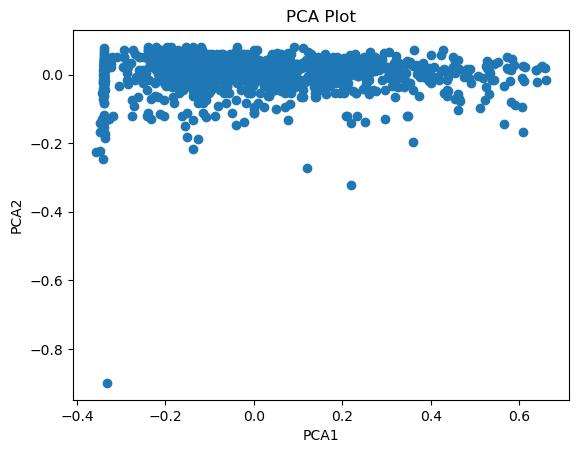

In [48]:
plt.scatter(merged_data['PCA1'], merged_data['PCA2'])
plt.title("PCA Plot")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [49]:
X = merged_data[['Funding']]
y = merged_data['Valuation']

In [50]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
print("\nRegression Coefficient:", model.coef_)


Regression Coefficient: [-3.44356187e-09]


In [52]:
train, test = train_test_split(
    merged_data,
    test_size=0.2,
    stratify=merged_data['Industry']
)

In [53]:
print("Sample shape:", train.shape)

Sample shape: (859, 14)


In [54]:
merged_data['Valuation_norm'] = MinMaxScaler().fit_transform(merged_data[['Valuation']])

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
merged_data['Funding_z'] = StandardScaler().fit_transform(merged_data[['Funding']])

In [59]:
bins = [0, 50, 100, np.inf]
labels = ['Low', 'Medium', 'High']
merged_data['Valuation_Level'] = pd.cut(merged_data['Valuation'], bins=bins, labels=labels)

In [60]:
hierarchy = {
    'Low': 'Small',
    'Medium': 'Growing',
    'High': 'Giant'
}

In [61]:
merged_data['Business_Size'] = merged_data['Valuation_Level'].map(hierarchy)

In [62]:
print("\nAfter Transformation:")
print(merged_data[['Valuation', 'Valuation_Level', 'Business_Size']].head())


After Transformation:
   Valuation Valuation_Level Business_Size
0      180.0            High         Giant
1      100.0          Medium       Growing
2      100.0          Medium       Growing
3       95.0          Medium       Growing
4       46.0             Low         Small


In [63]:
merged_data.to_csv("final_unicorn_output.csv", index=False)

In [64]:
print("\n✅ DONE! File saved as final_unicorn_output.csv")


✅ DONE! File saved as final_unicorn_output.csv
